Лабораторна робота №2
# "Логістична регресія та федеративне навчання"

**Мета:** Зрозуміти архітектуру багатокласової логістичної регресії, навчитися самостійно реалізовувати модель засобами numpy, зрозуміти принципи федеративного навчання, правильно розподілити дані між клієнтами та сервером, реалізувати агрегацію ваг та проаналізувати базові ефекти розподіленого навчання.

**Використаний датасет**: Dry Bean Dataset.
- **Цільова змінна**: Class (назва сорту квасолі).
- **Кількість класів**: 7 (багатокласова класифікація).
- **Ознаки**: числові фізичні характеристики зерен (площа, периметр, довжина, ширина тощо).

## **Етап 1**. Дослідження даних та попередня обробка 

### Дослідження даних

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("./data/dry+bean+dataset.xlsx")


Dataset shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  obj

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733



--- Categorical Features Statistics ---


,Class
count,13611
unique,7
top,DERMASON
freq,3546



--- Missing Values Count (Top 15) ---
Series([], dtype: int64)


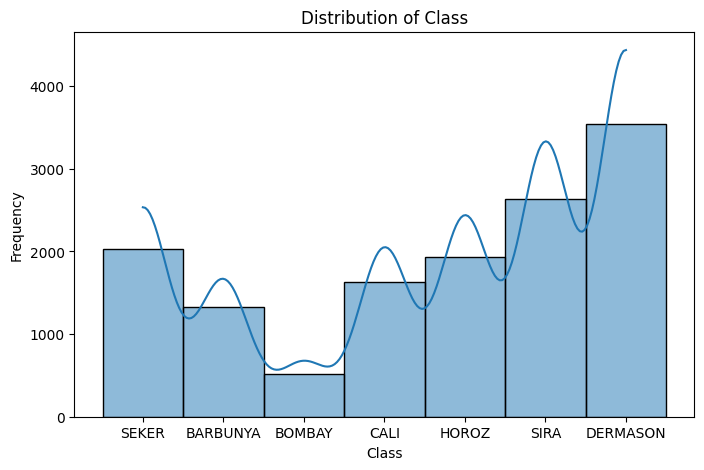

In [2]:
# Структура датасету
print("Dataset shape:", df.shape)
display(df.head())

# Типи ознак
print("\n--- Dataset Info ---")
df.info()

# Статистичні характеристики
# для числових
print("\n--- Numerical Features Statistics ---")
display(df.describe())

# для категоріальних
print("\n--- Categorical Features Statistics ---")
display(df.describe(include=['object']))

# Пропущені значення
print("\n--- Missing Values Count (Top 15) ---")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values.head(15))

# Розподіл цільової змінної
plt.figure(figsize=(8, 5))
sns.histplot(df['Class'], kde=True, bins=50)
plt.title('Distribution of Class')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

**<h4>Результати первинного аналізу датасету</h4>**

**Структура** <br>
Датасет містить 13611 рядків та 17 колонок (16 колонок з яких є числові, 1 - цільова). 

**Типи** <br>
Маємо поєднання int64 та float64 для числових колонок та тип obj - для категоріальної. 

**Пропущені значення** <br>
Пропущених значень немає. 

**Розподіл** <br>
Цільова змінна має 7 класів.

### Відбір ознак

--- Кореляція ознак з Class ---
ShapeFactor1       0.391907
roundness          0.384972
ShapeFactor2       0.335122
Solidity           0.321283
ShapeFactor3       0.167673
ShapeFactor4       0.165033
Compactness        0.156204
Extent            -0.031184
AspectRation      -0.116332
Eccentricity      -0.200356
MajorAxisLength   -0.455175
MinorAxisLength   -0.458492
Area              -0.475252
ConvexArea        -0.477459
EquivDiameter     -0.481099
Perimeter         -0.507638
dtype: float64


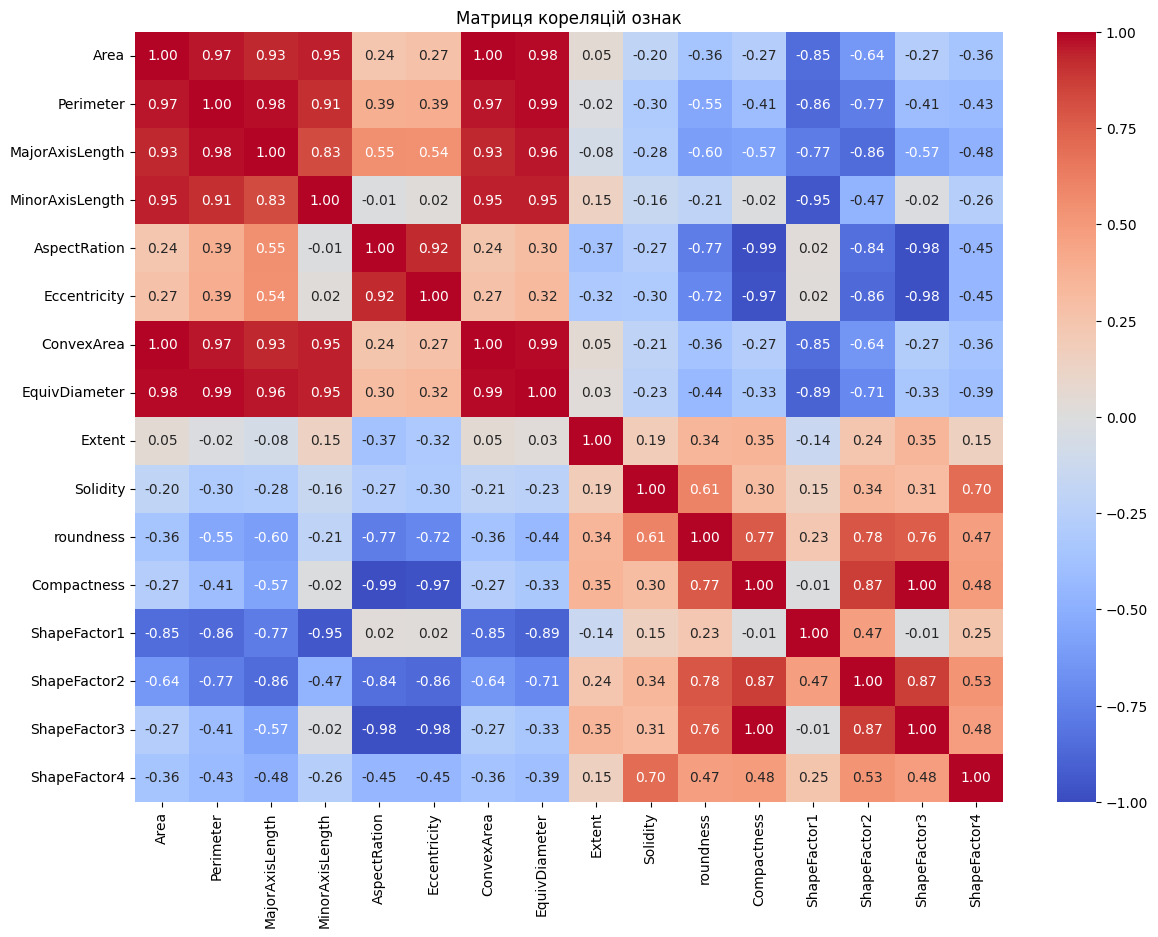

In [3]:
X_features = df.drop('Class', axis=1)

# Кодування Class для кореляції
class_codes = df['Class'].astype('category').cat.codes

correlations = (
    X_features.corrwith(class_codes)
    .sort_values(ascending=False)
)

print("--- Кореляція ознак з Class ---")
print(correlations)

# Побудова матриці кореляцій
plt.figure(figsize=(14, 10))
corr_matrix = X_features.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матриця кореляцій ознак')
plt.show()

In [4]:
columns_to_drop = [
    'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'EquivDiameter', # Дублюють Area
    'AspectRation', 'Compactness', 'ShapeFactor3' # Дублюють Eccentricity
]

df_reduced = df.drop(columns=columns_to_drop)

print("Ознаки, що залишилися для навчання: \n", df_reduced.columns.tolist())

Ознаки, що залишилися для навчання: 
 ['Area', 'Eccentricity', 'Extent', 'Solidity', 'roundness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor4', 'Class']


In [5]:
from sklearn.model_selection import train_test_split

X = df_reduced.drop('Class', axis=1)
y = df_reduced['Class']

#  Global Test 15%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Global Validation (15% від початкового розміру)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1764, random_state=42, stratify=y_temp
)

print(f"FL Train Pool розмір: {X_train.shape}")
print(f"Validation розмір: {X_val.shape}")
print(f"Test розмір: {X_test.shape}")

FL Train Pool розмір: (9528, 8)
Validation розмір: (2041, 8)
Test розмір: (2042, 8)


In [6]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

y_ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, X.columns.tolist())
    ],
    remainder='drop'
)

X_train_processed = preprocessor.fit_transform(X_train)

# Кодуємо цільову змінну окремо
y_train_processed = y_ohe.fit_transform(y_train.to_frame())
y_val_processed = y_ohe.transform(y_val.to_frame())
y_test_processed = y_ohe.transform(y_test.to_frame())

# Для Val та Test - робимо тільки transform
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)


X_train_final = pd.DataFrame(X_train_processed, index=X_train.index)
X_val_final = pd.DataFrame(X_val_processed, index=X_val.index)
X_test_final = pd.DataFrame(X_test_processed, index=X_test.index)

display(X_train_final.head())

,0,1,2,3,4,5,6,7
449,-0.577278,-1.802482,0.124986,0.134142,0.749512,0.033552,1.601930,0.860469
7444,-0.646813,0.399691,-0.182716,0.334689,0.338008,1.100490,0.169243,0.479122
6556,0.048543,1.128053,-2.466124,-0.423941,-0.983246,0.150152,-1.027437,-0.544348
1385,-0.390205,-0.741131,0.056746,0.552281,0.929942,-0.076292,0.691617,0.891095
8793,-0.280084,0.230434,-1.345432,0.803350,0.171433,0.116982,-0.096148,0.498736


## **Етап 2**. Реалізація багатокласової логістичної регресії 

In [7]:
import numpy as np

class LogisticRegression:
    def __init__(self):
        self.W = None
        self.b = None

    def initialize_parameters(self, n_features, n_classes):
        # W: розмірність (d x C), де d - кількість ознак, C - кількість класів
        self.W = np.zeros((n_features, n_classes))
        # b: розмірність (1 x C)
        self.b = np.zeros((1, n_classes))

    def softmax(self, Z):
        # Віднімаємо максимум по кожному рядку для стабільності
        Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z_shifted)
        P = exp_Z / np.sum(exp_Z, axis=1, keepdims=True)
        return P

    def predict_proba(self, X):
        # Лінійна частина моделі
        Z = np.dot(X, self.W) + self.b
        # Ймовірності класів
        return self.softmax(Z)

    def predict(self, X):
        # Отримуємо матрицю ймовірностей (m x C)
        P = self.predict_proba(X)
        # Повертаємо індекс класу з максимальною ймовірністю для кожного прикладу
        return np.argmax(P, axis=1)

    def compute_loss(self, Y, P, lambda_reg):
        m = Y.shape[0]
        eps = 1e-15 
        
        cross_entropy_loss = - (1 / m) * np.sum(Y * np.log(P + eps))
        ridge_reg = (lambda_reg / 2) * np.sum(self.W ** 2)
        
        return cross_entropy_loss + ridge_reg

    def compute_gradients(self, X, Y, P, lambda_reg):
        m = X.shape[0]
        
        dW = (1 / m) * np.dot(X.T, (P - Y)) + lambda_reg * self.W
        db = (1 / m) * np.sum(P - Y, axis=0, keepdims=True)
        
        return dW, db
        
    # Структура для навчання (міні-батчі)
    def fit(self, X, Y, epochs=100, batch_size=32, lr=0.01, lambda_reg=0.1):
        n_samples, n_features = X.shape
        n_classes = Y.shape[1]
        
        self.initialize_parameters(n_features, n_classes)
        
        # Історія втрат для графіка
        loss_history = []
        
        for epoch in range(epochs):
            # Перемішуємо дані для батчів
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]
            
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                Y_batch = Y_shuffled[i:i+batch_size]
                
                # Передбачення
                P_batch = self.predict_proba(X_batch)
                
                # Градієнти
                dW, db = self.compute_gradients(X_batch, Y_batch, P_batch, lambda_reg)
                
                # Оновлення ваг
                self.W = self.W - lr * dW
                self.b = self.b - lr * db
                
            # Обчислення loss після кожної епохи
            P_all = self.predict_proba(X)
            loss = self.compute_loss(Y, P_all, lambda_reg)
            loss_history.append(loss)
            
        return loss_history

## **Етап 3**. Центрально навчана базова модель

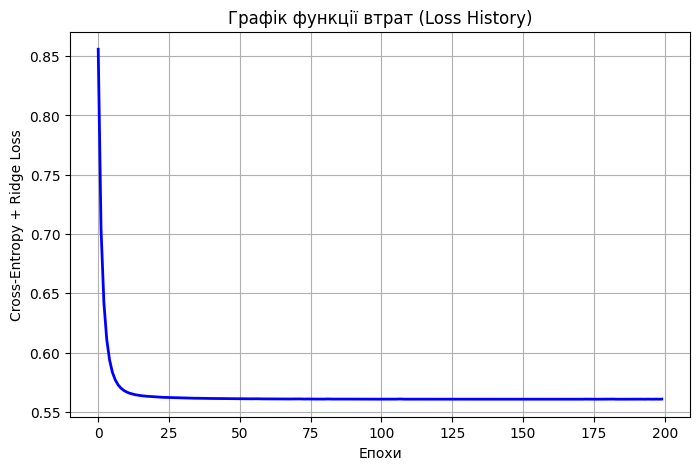

--- Метрики на Global Test ---
Accuracy:          0.9084
Macro-F1:          0.9212
Balanced Accuracy: 0.9187
Log-Loss:          0.3967


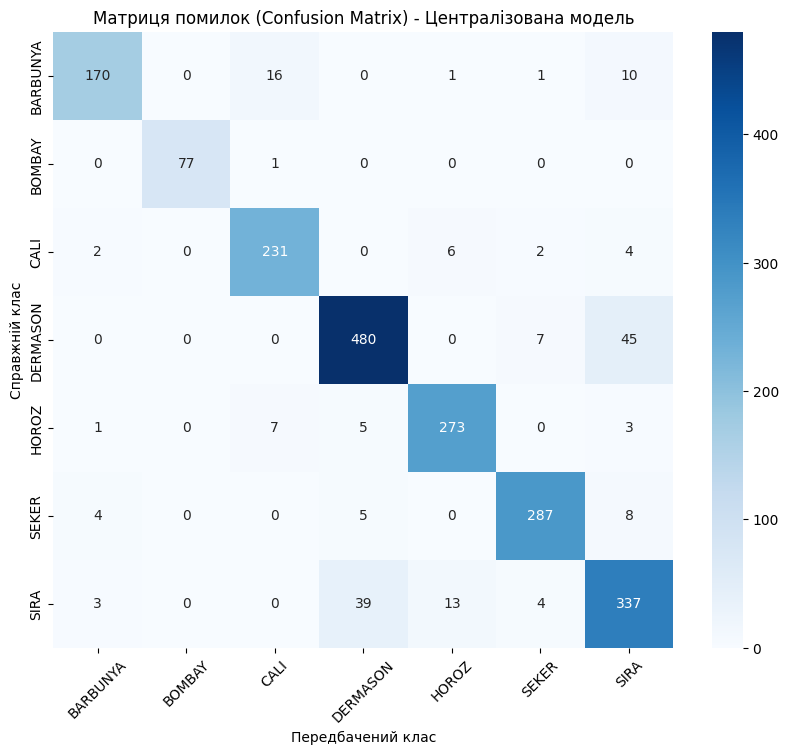

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, log_loss, confusion_matrix

# Ініціалізація та навчання моделі
model = LogisticRegression()

# Гіперпараметри 
epochs = 200
batch_size = 64
lr = 0.05
lambda_reg = 0.01

# Навчаємо модель 
loss_history = model.fit(X_train_final.values, y_train_processed, 
                         epochs=epochs, batch_size=batch_size, 
                         lr=lr, lambda_reg=lambda_reg)

# Графік навчання (Loss)
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('Графік функції втрат (Loss History)')
plt.xlabel('Епохи')
plt.ylabel('Cross-Entropy + Ridge Loss')
plt.grid(True)
plt.show()

# Оцінка моделі на Global Test
# Передбачаємо ймовірності та індекси класів
P_test = model.predict_proba(X_test_final.values)
y_test_pred_indices = model.predict(X_test_final.values)

# Перетворюємо індекси назад у текстові назви класів
class_names = y_ohe.categories_[0]
y_test_pred_names = class_names[y_test_pred_indices]

# Обчислення метрик
acc = accuracy_score(y_test, y_test_pred_names)
macro_f1 = f1_score(y_test, y_test_pred_names, average='macro')
bal_acc = balanced_accuracy_score(y_test, y_test_pred_names)
# log_loss приймає справжні мітки (y_test) та передбачені ймовірності (P_test)
logloss_val = log_loss(y_test, P_test) 

print("--- Метрики на Global Test ---")
print(f"Accuracy:          {acc:.4f}")
print(f"Macro-F1:          {macro_f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Log-Loss:          {logloss_val:.4f}")

# Візуалізація Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_names, labels=class_names)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Матриця помилок (Confusion Matrix) - Централізована модель')
plt.xlabel('Передбачений клас')
plt.ylabel('Справжній клас')
plt.xticks(rotation=45)
plt.show()

**<h4>Висновки щодо отриманих результатів навчання:</h4>**
- **Графік функції втрат:** <br>
Крива швидко і плавно спадає в перші 25-30 епох, після чого стабілізується. Це свідчить про те, що обрана швидкість навчання (lr=0.05) є оптимальною — модель не "застрягла" і градієнти не розійшлися. Регуляризація та міні-батчі забезпечили стабільну збіжність.   
- **Матриця помилок (Confusion Matrix):** <br> 
Модель чудово розпізнає класи BOMBAY (всі 77 екземплярів правильно) та CALI. Основні помилки класифікації виникають між сортами SIRA та DERMASON (45 зерен DERMASON розпізнано як SIRA, і 39 зерен SIRA розпізнано як DERMASON). Також є невелика плутанина між BARBUNYA та CALI (16 зерен). Це пояснюється тим, що ці сорти квасолі мають дуже схожі фізичні пропорції (ексцентриситет, площа), що робить їх важчими для лінійного розділення.  

## **Етап 4**. Розподіл даних між клієнтом та сервером

Створення IID розподілу...


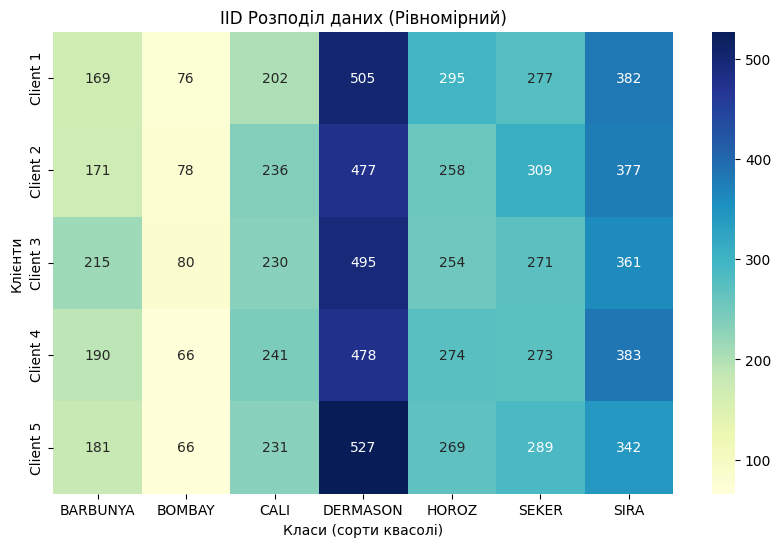

Створення Non-IID розподілу (alpha=0.3)...


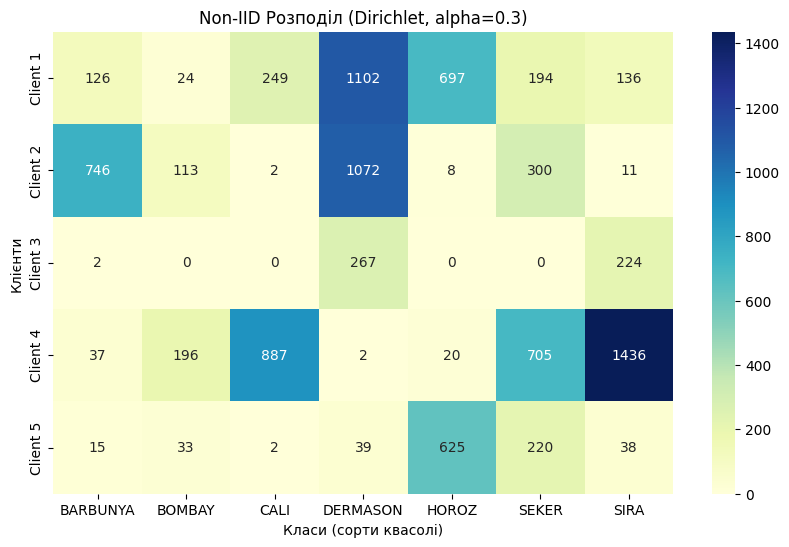

In [9]:
# Розподіл даних між K клієнтами
def distribute_data(X, y_indices, K=5, alpha=None, random_state=42):
    np.random.seed(random_state)
    n_samples = len(y_indices)
    classes = np.unique(y_indices)
    
    # Словник для збереження індексів даних кожного клієнта
    client_indices = {k: [] for k in range(K)}
    
    if alpha is None:
        # IID розподіл
        indices = np.random.permutation(n_samples)
        splits = np.array_split(indices, K)
        for k in range(K):
            client_indices[k] = splits[k].tolist()
    else:
        # Non-IID
        for c in classes:
            # Знаходимо всі індекси прикладів поточного класу
            c_idx = np.where(y_indices == c)[0]
            np.random.shuffle(c_idx)
            
            # Генеруємо пропорції розподілу цього класу між клієнтами
            proportions = np.random.dirichlet(np.repeat(alpha, K))
            proportions = np.array([p * len(c_idx) for p in proportions])
            
            # Розбиваємо індекси класу відповідно до пропорцій
            splits = np.cumsum(proportions).astype(int)[:-1]
            split_idx = np.split(c_idx, splits)
            
            for k in range(K):
                client_indices[k].extend(split_idx[k].tolist())
                
    # Формуємо локальні датасети для кожного клієнта
    clients_data = {}
    for k in range(K):
        np.random.shuffle(client_indices[k]) # Перемішуємо дані клієнта
        idx = client_indices[k]
        # Зберігаємо X та оригінальні мітки класів (індекси)
        clients_data[k] = {
            'X': X[idx],
            'y': y_indices[idx]
        }
        
    return clients_data

def plot_client_distribution(clients_data, class_names, title="Розподіл класів між клієнтами"):
    K = len(clients_data)
    n_classes = len(class_names)
    dist_matrix = np.zeros((K, n_classes), dtype=int)
    
    for k in range(K):
        y_local = clients_data[k]['y']
        unique, counts = np.unique(y_local, return_counts=True)
        for c, count in zip(unique, counts):
            dist_matrix[k, int(c)] = count
            
    df_dist = pd.DataFrame(dist_matrix, columns=class_names, index=[f"Client {k+1}" for k in range(K)])
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_dist, annot=True, fmt="d", cmap="YlGnBu")
    plt.title(title)
    plt.ylabel('Клієнти')
    plt.xlabel('Класи (сорти квасолі)')
    plt.show()

# Перетворюємо OHE цільову змінну тренувальної вибірки назад в індекси для розподілу
y_train_indices = np.argmax(y_train_processed, axis=1)

# Створюємо 5 клієнтів
K_CLIENTS = 5

# 1. IID Розподіл
print("Створення IID розподілу...")
clients_data_iid = distribute_data(X_train_final.values, y_train_indices, K=K_CLIENTS, alpha=None)
plot_client_distribution(clients_data_iid, class_names, title="IID Розподіл даних (Рівномірний)")

# 2. Non-IID Розподіл (сильна неоднорідність, alpha=0.3)
print("Створення Non-IID розподілу (alpha=0.3)...")
clients_data_non_iid = distribute_data(X_train_final.values, y_train_indices, K=K_CLIENTS, alpha=0.3)
plot_client_distribution(clients_data_non_iid, class_names, title="Non-IID Розподіл (Dirichlet, alpha=0.3)")

**<h4>Висновки щодо розподілу:</h4>**
- **IID Розподіл (Рівномірний):** <br>
Теплова карта показує, що кожен із 5 клієнтів отримав приблизно однакову кількість зерен кожного сорту. Наприклад, сорт DERMASON рівномірно розподілився по ~470-520 прикладів на клієнта. Локальні датасети є репрезентативними зменшеними копіями глобального датасету.   
- **Non-IID Розподіл ($\alpha=0.3$):** <br> 
Розподіл Діріхле створив сильну неоднорідність. Деякі клієнти стали монополістами певних сортів: Клієнт 4 отримав майже половину всіх зерен SIRA (1436) та CALI (887), але майже не має DERMASON (2). Клієнт 3 взагалі не містить прикладів класів BOMBAY, CALI, HOROZ та SEKER. У таких умовах локальні моделі будуть сильно "перекошуватися" під ті класи, які вони бачать (клієнтський дрейф).  

## **Етап 5**. Реалізація федеративного навчання

Навчання на IID даних...
Навчання на Non-IID даних...


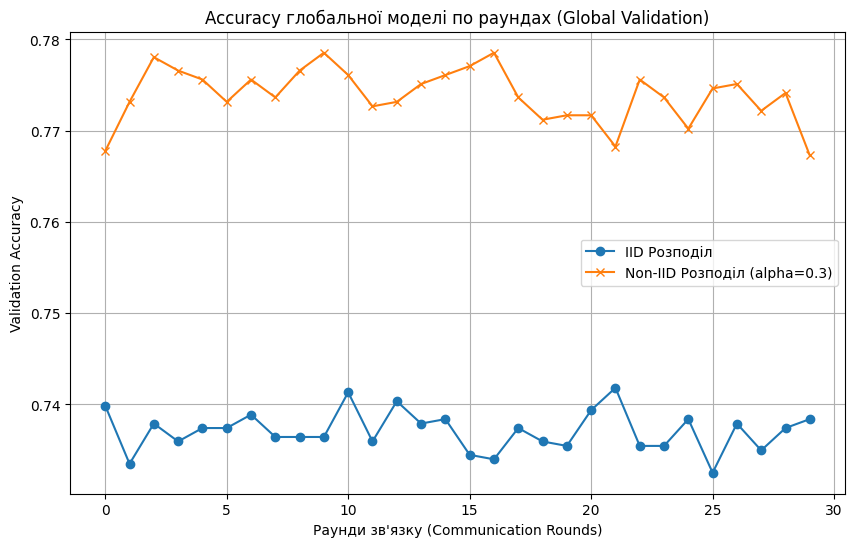

In [10]:
import copy

def evaluate_model(model, X, y):
    P = model.predict_proba(X)
    y_pred = np.argmax(P, axis=1)
    return accuracy_score(y, y_pred)

def fedavg_simulation(clients_data, X_val, y_val_indices, n_features, n_classes, 
                      n_rounds=20, local_epochs=1, lr=0.05, lambda_reg=0.01):
    
    # Сервер ініціалізує глобальну модель
    global_model = LogisticRegression()
    global_model.initialize_parameters(n_features, n_classes)
    
    global_acc_history = []
    
    for r in range(n_rounds):
        client_weights = []
        client_biases = []
        client_sizes = []
        
        # Локальне навчання на клієнтах
        for k in clients_data.keys():
            X_local = clients_data[k]['X']
            y_local_indices = clients_data[k]['y']
            n_local_samples = len(X_local)
            
            # Пропускаємо клієнта, якщо в нього 0 прикладів (може статися при дуже малій alpha)
            if n_local_samples == 0:
                continue
            
            # OHE для локальних міток
            y_local_ohe = np.zeros((n_local_samples, n_classes))
            y_local_ohe[np.arange(n_local_samples), y_local_indices] = 1
            
            # Клієнт отримує копію глобальної моделі
            local_model = LogisticRegression()
            local_model.W = copy.deepcopy(global_model.W)
            local_model.b = copy.deepcopy(global_model.b)
            
            # Клієнт навчає модель локально (E епох)
            local_model.fit(X_local, y_local_ohe, epochs=local_epochs, batch_size=32, 
                            lr=lr, lambda_reg=lambda_reg)
            
            # Клієнт повертає оновлені параметри серверу
            client_weights.append(local_model.W)
            client_biases.append(local_model.b)
            client_sizes.append(n_local_samples)
            
        # Агрегація параметрів на сервері
        total_samples = sum(client_sizes)
        new_W = np.zeros_like(global_model.W)
        new_b = np.zeros_like(global_model.b)
        
        for i in range(len(client_weights)):
            # Зважування за кількістю прикладів (n_k / N)
            weight = client_sizes[i] / total_samples
            new_W += weight * client_weights[i]
            new_b += weight * client_biases[i]
            
        global_model.W = new_W
        global_model.b = new_b
        
        # Оцінка глобальної моделі на сервері (Global Validation)
        acc = evaluate_model(global_model, X_val, y_val_indices)
        global_acc_history.append(acc)
        # print(f"Раунд {r+1:02d} | Глобальна Validation Accuracy: {acc:.4f}")
        
    return global_model, global_acc_history

# Параметри для ініціалізації
N_FEATURES = X_train_final.shape[1]
N_CLASSES = len(class_names)
y_val_indices = np.argmax(y_val_processed, axis=1)

# Запуск симуляції для IID даних (1 локальна епоха)
print("Навчання на IID даних...")
global_model_iid, acc_history_iid = fedavg_simulation(
    clients_data_iid, X_val_final.values, y_val_indices, N_FEATURES, N_CLASSES, 
    n_rounds=30, local_epochs=1, lr=0.05
)

# Запуск симуляції для Non-IID даних (1 локальна епоха)
print("Навчання на Non-IID даних...")
global_model_non_iid, acc_history_non_iid = fedavg_simulation(
    clients_data_non_iid, X_val_final.values, y_val_indices, N_FEATURES, N_CLASSES, 
    n_rounds=30, local_epochs=1, lr=0.05
)

# Візуалізація прогресу навчання по раундах
plt.figure(figsize=(10, 6))
plt.plot(acc_history_iid, label='IID Розподіл', marker='o')
plt.plot(acc_history_non_iid, label='Non-IID Розподіл (alpha=0.3)', marker='x')
plt.title('Accuracy глобальної моделі по раундах (Global Validation)')
plt.xlabel('Раунди зв\'язку (Communication Rounds)')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

**Питання**: Чому ваги клієнтів доцільно зважувати за кількістю прикладів? Що станеться, якщо використовувати просте середнє без зважування? <br>
Зважування гарантує, що клієнти з великим обсягом даних матимуть більший вплив на формування глобальної моделі. Це математично наближає агрегований градієнт до істинного градієнта, який був би обчислений на об'єднаному централізованому датасеті. Якщо агрегувати ваги простим середнім ($1/K$), то клієнт з 10 прикладами матиме такий самий вплив, як і клієнт із 2000 прикладів. Це призведе до деградації глобальної моделі, оскільки вона буде сильно перенавчатися на шумі та статистичних викидах від клієнтів з малим обсягом даних.

## **Етап 6**. Дослідження ефектів федеративного навчання

### **Експеримент 1**: Вплив неоднорідності даних ($\alpha$)

Запуск симуляцій для Експерименту 1...
Навчання для alpha=5...
Навчання для alpha=1...
Навчання для alpha=0.3...


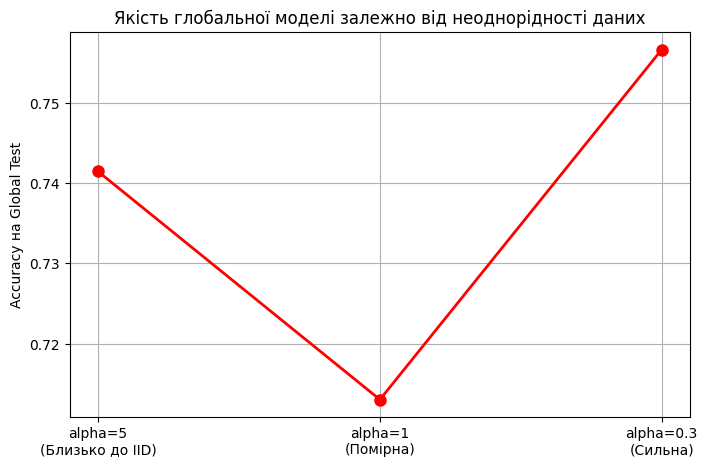

In [11]:
alphas = [5, 1, 0.3]
alpha_accuracies = []
y_test_indices = np.argmax(y_test_processed, axis=1)

print("Запуск симуляцій для Експерименту 1...")
for a in alphas:
    print(f"Навчання для alpha={a}...")
    clients_data_a = distribute_data(X_train_final.values, y_train_indices, K=K_CLIENTS, alpha=a)
    g_model, acc_hist = fedavg_simulation(
        clients_data_a, X_val_final.values, y_val_indices, N_FEATURES, N_CLASSES, 
        n_rounds=20, local_epochs=1, lr=0.05
    )
    # Оцінка на Global Test
    P_test = g_model.predict_proba(X_test_final.values)
    y_pred = np.argmax(P_test, axis=1)
    acc = accuracy_score(y_test_indices, y_pred)
    alpha_accuracies.append(acc)

# Графік залежності
plt.figure(figsize=(8, 5))
plt.plot(['alpha=5\n(Близько до IID)', 'alpha=1\n(Помірна)', 'alpha=0.3\n(Сильна)'], 
         alpha_accuracies, marker='o', color='red', markersize=8, linewidth=2)
plt.title('Якість глобальної моделі залежно від неоднорідності даних')
plt.ylabel('Accuracy на Global Test')
plt.grid(True)
plt.show()

На графіку спостерігається нелінійна залежність: при переході від альфа=5 (близько до IID) до альфа=1 якість очікувано падає з ~0.74 до ~0.71, але при сильній неоднорідності (альфа=0.3) раптово зростає майже до 0.76. <br>   
**Чому так відбувається:** Падіння якості від альфа=5 до альфа=1 повністю підтверджує теорію — неоднорідні дані ускладнюють збіжність глобальної моделі, оскільки локальні градієнти спрямовані в різні боки, оптимізуючи локальні функції втрат. Аномальне зростання при альфа=0.3 найімовірніше пояснюється специфікою конкретного розбиття (вплив random seed): алгоритм Діріхле міг розподілити дані так, що локальні моделі вдало доповнили одна одну під час агрегації FedAvg без критичних розбіжностей ваг. 

**Чому Non-IID погіршує навчання:** <br> 
Клієнти оптимізують локальну функцію втрат лише для тих класів, які є в їхньому датасеті. Локальні градієнти починають вказувати в абсолютно різні боки (в локальні мінімуми). Коли сервер усереднює ці різноспрямовані вектори ваг, загальна модель втрачає здатність добре розпізнавати всі класи одночасно. <br>   
**Чи може глобальна модель бути гіршою за централізовану?** <br>
Так, майже завжди на Non-IID даних. Централізована модель "бачить" увесь збалансований датасет одночасно і рухається прямо до глобального мінімуму, тоді як федеративна модель збирається з "викривлених" шматків. <br>   
**Чи може глобальна модель бути гіршою за локальну?** <br> 
Так, на локальних даних конкретного клієнта. Якщо клієнт має лише 2 сорти квасолі, його локальна модель ідеально навчиться розрізняти лише їх. Глобальна модель, якій треба розрізняти всі 7 сортів, може показати гірший результат на цих двох конкретних сортах через компроміс у вагах.

### **Експеримент 2**: Вплив кількості локальних епох ($E$)

Запуск симуляцій для Експерименту 2 (на Non-IID даних alpha=0.3)...
Навчання для E=1 локальних епох...
Навчання для E=5 локальних епох...
Навчання для E=10 локальних епох...


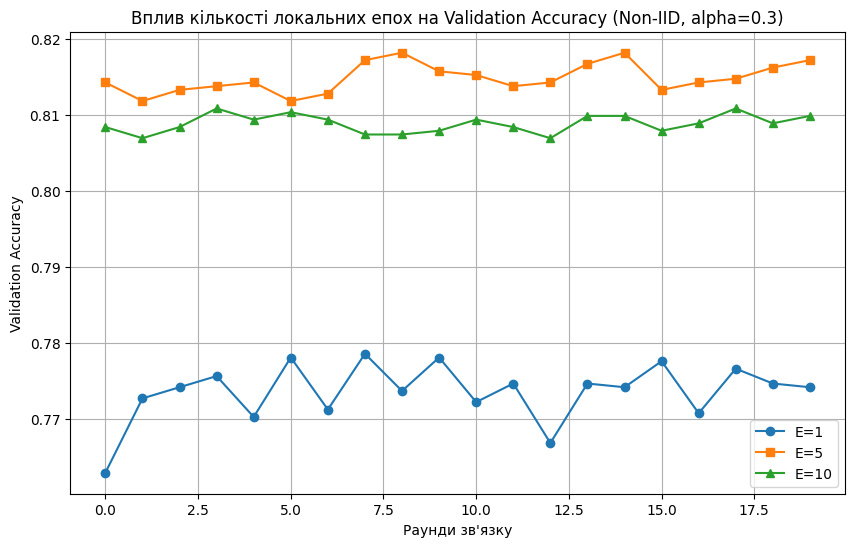

In [12]:
epochs_list = [1, 5, 10]
epochs_histories = {}

print("Запуск симуляцій для Експерименту 2 (на Non-IID даних alpha=0.3)...")
# Використовуємо розподіл clients_data_non_iid з попереднього етапу
for e in epochs_list:
    print(f"Навчання для E={e} локальних епох...")
    g_model, acc_hist = fedavg_simulation(
        clients_data_non_iid, X_val_final.values, y_val_indices, N_FEATURES, N_CLASSES, 
        n_rounds=20, local_epochs=e, lr=0.05
    )
    epochs_histories[e] = acc_hist

# Візуалізація
plt.figure(figsize=(10, 6))
for e in epochs_list:
    plt.plot(epochs_histories[e], label=f'E={e}', marker='o' if e==1 else 's' if e==5 else '^')
plt.title('Вплив кількості локальних епох на Validation Accuracy (Non-IID, alpha=0.3)')
plt.xlabel('Раунди зв\'язку')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Найкращий результат та найвищу Validation Accuracy дає навчання з E=5 епохами (значення тримається в районі 0.81-0.82). Значення E=1 дає найгірший результат (~0.77), а E=10 показує якість трохи гіршу, ніж E=5. <br>   
**Чому так відбувається:** При E=1 локальні моделі роблять надто мало кроків градієнтного спуску, тому глобальна модель сходиться дуже повільно (Underfitting). Значення E=5 виявилося оптимальним балансом. А от зниження якості при E=10 порівняно з E=5 чудово ілюструє явище клієнтського дрейфу (client drift): клієнти роблять забагато кроків на своїх викривлених (Non-IID) даних, через що їхні локальні моделі перенавчаються під власну специфіку. При подальшому усередненні таких розбіжних ваг на сервері загальна якість агрегованої моделі падає. 

### Порівняльна таблиця (Global Test)

In [13]:
# Навчання однієї Локальної моделі
local_model = LogisticRegression()
local_model.initialize_parameters(N_FEATURES, N_CLASSES)
X_local = clients_data_non_iid[0]['X']
y_local_idx = clients_data_non_iid[0]['y']
y_local_ohe = np.zeros((len(X_local), N_CLASSES))
y_local_ohe[np.arange(len(X_local)), y_local_idx] = 1
local_model.fit(X_local, y_local_ohe, epochs=150, lr=0.05)

# Функція для швидкого підрахунку метрик
def get_metrics(eval_model, X_test, y_test_true_idx):
    P_test = eval_model.predict_proba(X_test)
    y_pred = np.argmax(P_test, axis=1)
    
    acc = accuracy_score(y_test_true_idx, y_pred)
    f1 = f1_score(y_test_true_idx, y_pred, average='macro')
    bal_acc = balanced_accuracy_score(y_test_true_idx, y_pred)
    ll = log_loss(y_test_true_idx, P_test)
    return [acc, f1, bal_acc, ll]

# Отримуємо метрики для трьох моделей
metrics_centralized = get_metrics(model, X_test_final.values, y_test_indices) # model - з Етапу 3
metrics_global = get_metrics(global_model_non_iid, X_test_final.values, y_test_indices) # alpha=0.3
metrics_local = get_metrics(local_model, X_test_final.values, y_test_indices)

# Створення таблиці
df_metrics = pd.DataFrame([metrics_centralized, metrics_global, metrics_local], 
                          columns=['Accuracy', 'Macro-F1', 'Balanced Accuracy', 'Log-Loss'],
                          index=['Централізована', 'Глобальна (Non-IID)', 'Локальна (Клієнт 0)'])

print("--- Зведена таблиця метрик на Global Test ---")
display(df_metrics.round(4))

--- Зведена таблиця метрик на Global Test ---


,Accuracy,Macro-F1,Balanced Accuracy,Log-Loss
Централізована,0.9084,0.9212,0.9187,0.3967
Глобальна (Non-IID),0.7561,0.7539,0.7666,1.1729
Локальна (Клієнт 0),0.5744,0.4442,0.4875,1.0789


**Що таке client drift (клієнтський дрейф):** <br>
Це явище, коли в умовах Non-IID даних локальні моделі клієнтів занадто сильно підлаштовуються під свої специфічні дані і "відпливають" далеко від глобальної моделі. <br>

**Вплив великої кількості епох:** <br>
Графік показує, що при $E=10$ глобальна модель навчається нестабільно або показує гірший результат. Чим більше локальних епох робить клієнт перед агрегацією, тим далі його ваги відхиляються в локальний оптимум. Усереднення таких сильно розбіжних моделей псує глобальну модель.   

**<h2>Загальний висновок</h2>**
У ході лабораторної роботи було реалізовано алгоритм багатокласової логістичної регресії та проведено симуляцію федеративного навчання за алгоритмом FedAvg. <br>   
Проведений EDA та кореляційний аналіз дозволили виявити і усунути мультиколінеарність ознак. Строге дотримання послідовності — спочатку розбиття на множини (Global Test, Validation, FL Train Pool), а потім масштабування — дозволило уникнути витоку даних (Data Leakage) та забезпечило об'єктивну оцінку моделі. <br>
Централізована модель логістичної регресії показала високу точність на тестовій вибірці (Accuracy ~91%), що підтверджує правильність реалізації функції softmax із стабілізацією, крос-ентропії з Ridge-регуляризацією та векторизованого обчислення градієнтів. <br>   
Експерименти з розподілом Діріхле довели, що федеративне навчання добре працює на рівномірних (IID) даних, але стикається зі складнощами при Non-IID розподілі. Що сильніша неоднорідність (менше значення $\alpha$), то важче глобальній моделі досягти якості централізованої моделі через різноспрямованість локальних оптимумів. <br>   
Дослідження кількості локальних епох ($E$) яскраво продемонструвало проблему дрейфу ваг. Занадто мала кількість епох ($E=1$) призводить до недонавчання, тоді як завелика ($E=10$) на Non-IID даних змушує клієнтські моделі занадто сильно перенавчатися під власні специфічні дані. Це псує процес агрегації на сервері, тому вибір оптимальної кількості епох (у нашому випадку $E=5$) є критично важливим для стабільної збіжності. <br>   
Підтверджено необхідність зважування параметрів локальних моделей пропорційно до кількості тренувальних прикладів клієнта ($n_k$). Це дозволяє уникнути зміщення глобальної моделі в бік клієнтів з малим, але нерепрезентативним обсягом даних.